# 04. K-Nearest Neighbors (KNN)

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement k-NN classification and choose k
- Use distance metrics and scaling
- Compare with other classifiers

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 04. K-Nearest Neighbors (KNN)

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 3, Examples 1-3**: Logistic Regression, Decision Trees, and SVM
- ✅ **Understanding of distance metrics**: Euclidean distance, Manhattan distance
- ✅ **Understanding of feature scaling**: Why scaling matters for distance-based algorithms

**If you haven't completed these**, you might struggle with:
- Understanding how KNN makes predictions based on neighbors
- Knowing why feature scaling is critical for KNN
- Understanding how to choose the right K value

---

## 🔗 Where This Notebook Fits

**This is Unit 3, Example 4** - it introduces instance-based classification!

**Why this example FOURTH in Unit 3?**
- **Before** you can use KNN, you need to understand basic classification
- **Before** you can choose K, you need to understand overfitting vs underfitting
- **Before** you can use distance metrics, you need to understand feature scaling

**Builds on**: 
- 📓 Unit 3, Example 1: Logistic Regression (classification basics)
- 📓 Unit 3, Example 2: Decision Trees (overfitting concepts)
- 📓 Unit 3, Example 3: SVM (feature scaling importance)

**Leads to**: 
- 📓 Unit 4: Clustering (K-Means uses similar distance concepts)
- 📓 Unit 5: Model Selection (hyperparameter tuning for K)
- 📓 All instance-based learning algorithms

**Why this order?**
1. KNN is **simple to understand** (just find nearest neighbors)
2. KNN demonstrates **lazy learning** (no training, just prediction)
3. KNN shows **distance-based classification** (different from other methods)

---

## The Story: Learning from Neighbors

Imagine you're moving to a new neighborhood. **Before** KNN, you make decisions alone. **After** KNN, you look at your neighbors: "What do most of my neighbors do? I'll do that too!" - simple and effective!

Same with machine learning: **Before** KNN, we train complex models. **After** KNN, we just find the nearest neighbors and predict based on them - simple but powerful!

---

## What is KNN?

**K-Nearest Neighbors (KNN) is a classification algorithm that makes predictions by finding the K closest data points (neighbors) and using majority vote.**

### How KNN Works

1. **Store All Data**: KNN stores all training data (no model training!)
2. **For New Point**: When predicting, find the K nearest neighbors
3. **Calculate Distances**: Measure distance to all training points
4. **Select K Nearest**: Pick the K closest points
5. **Vote**: Majority class of K neighbors = prediction

### Simple Example

**Predicting if a transaction is fraud:**
```
New Transaction: [Amount=$500, Time=1200, ...]

Step 1: Calculate distances to all training transactions
Step 2: Find 5 nearest neighbors (K=5)
  - Neighbor 1: Fraud ✅ (distance: 0.5)
  - Neighbor 2: Legitimate ❌ (distance: 0.7)
  - Neighbor 3: Fraud ✅ (distance: 0.8)
  - Neighbor 4: Fraud ✅ (distance: 0.9)
  - Neighbor 5: Legitimate ❌ (distance: 1.0)

Step 3: Majority vote: 3 Fraud, 2 Legitimate
Step 4: Prediction: FRAUD ✅
```

### Key Concepts
- **K**: Number of neighbors to consider (hyperparameter - must choose!)
- **Distance Metric**: How to measure "nearest" (Euclidean, Manhattan, etc.)
- **Lazy Learning**: No training phase - all computation happens during prediction
- **Feature Scaling**: CRITICAL! Distance calculations depend on feature scales

### Why KNN Matters

KNN is a simple but powerful classifier:
- **Simple**: Easy to understand and implement
- **No Training**: Lazy learning - no model training needed
- **Non-Parametric**: Makes no assumptions about data distribution
- **Versatile**: Works for classification and regression
- **Effective**: Often performs well on many datasets

---

## 🌍 Real-World Applications

**KNN is widely used for simple, effective classification!** Key applications:

### 🏥 Healthcare & Medical Sector
- **Disease Diagnosis**: Find patients with similar symptoms → predict disease (similar patients = similar outcomes)
- **Drug Recommendation**: Find patients similar to current patient → recommend same treatment
- **Medical Image Classification**: Find similar medical images → classify new images

### 💰 Finance & Banking Sector
- **Credit Scoring**: Find similar loan applicants → predict default risk (similar applicants = similar risk)
- **Fraud Detection**: Find similar transactions → identify fraudulent patterns
- **Customer Segmentation**: Find similar customers → group them together

### 🏛️ Government & Public Safety Sector (GDI)
- **Financial Fraud Detection**: Find similar transactions → identify fraudulent patterns → financial investigations
- **Administrative Crimes Detection**: Find similar administrative violations → detect patterns → administrative crime investigation
- **Identity Matching**: Find similar faces/identities to query person → identify suspects, verify identity → security systems

### 💡 Why KNN is Popular:
- **Simple**: Easy to understand and implement
- **No Assumptions**: Works with any data distribution
- **Effective**: Often performs well
- **Interpretable**: Can explain predictions (show similar examples)
- **Adaptive**: Automatically adapts to new data
- **Baseline**: Good baseline before trying complex models

### 📈 When to Use KNN:
✅ **Use KNN when:**
- Need simple, interpretable model
- Have small to medium datasets (KNN is slow on large datasets)
- Want to see similar examples (interpretability)
- Data has local patterns (similar items are nearby)
- Need quick prototype (no training needed)
- Want baseline model before complex algorithms

❌ **Don't use KNN when:**
- Have very large datasets (KNN is slow - must compute distances to all points)
- Need fast predictions (KNN is slow for prediction)
- Have many irrelevant features (KNN uses all features)
- Data has high dimensionality (curse of dimensionality)
- Need probability outputs (KNN gives class, not probability)
- Have streaming data (KNN needs all data in memory)

---

## Learning Objectives
1. Build KNN classifiers
2. Understand how KNN makes predictions (nearest neighbors)
3. Choose the right K value (avoid overfitting/underfitting)
4. Understand distance metrics (Euclidean, Manhattan)
5. Know why feature scaling is critical for KNN
6. Compare KNN with other classification algorithms
7. Understand when to use KNN vs other methods

---

## 📋 Notebook Structure

**This notebook is organized into clear sections:**

**Part 1: Understanding KNN** (The Concept)
- What is KNN and how it works
- Why feature scaling is critical
- Load and prepare credit card fraud dataset

**Part 2: Building KNN Models** (Main Content)
- Demonstrate feature scaling importance (scaled vs unscaled)
- Find optimal K value
- Train final model and evaluate comprehensively

**Part 3: Decision Framework** (When to Use KNN)
- Compare KNN with other algorithms
- Understand when KNN is the right choice
- Summary and next steps

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us build KNN classification models

import pandas as pd # For data manipulation
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For visualizations
import seaborn as sns # For beautiful plots (confusion matrix heatmap)
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.preprocessing import StandardScaler # CRITICAL for KNN! Must scale features
from sklearn.neighbors import KNeighborsClassifier # The KNN classifier!
from sklearn.metrics import (
 accuracy_score, # Accuracy: % of correct predictions
 precision_score, # Precision: Of predicted positives, how many are actually positive?
 recall_score, # Recall: Of actual positives, how many did we catch?
 f1_score, # F1: Harmonic mean of precision and recall
 classification_report, # Comprehensive classification metrics
 confusion_matrix, # Shows true/false positives/negatives
 roc_auc_score, roc_curve, # AUC score, ROC curve
)

print("✅ Libraries imported successfully!")
print("\n📚 Key KNN Concepts:")
print(" - KNeighborsClassifier: The KNN model (lazy learning - no training phase!)")
print(" - K (n_neighbors): Number of neighbors used for the majority vote")
print(" - Distance metric: Euclidean distance by default")
print("\n ⚠️ IMPORTANT: KNN is distance-based - always scale features with StandardScaler!")

✅ Libraries imported successfully!

📚 Key KNN Concepts:
 - KNeighborsClassifier: The KNN model (lazy learning - no training phase!)
 - K (n_neighbors): Number of neighbors used for the majority vote
 - Distance metric: Euclidean distance by default

 ⚠️ IMPORTANT: KNN is distance-based - always scale features with StandardScaler!


## Part 1: Understanding KNN

### 🔗 Connecting to Previous Notebooks

**What We've Learned So Far:**
- ✅ **Logistic Regression**: Linear classifier, needs scaling, interpretable
- ✅ **Decision Trees**: Non-linear, interpretable, can overfit, no scaling needed
- ✅ **SVM**: Optimal margin boundaries, needs scaling, handles non-linear with kernels

**What Makes KNN Different:**
- **No Training**: KNN doesn't train a model - it's "lazy learning" (stores all data)
- **Distance-Based**: Uses distance to find similar examples (like SVM, but simpler)
- **Simple**: Just find nearest neighbors and vote (no complex optimization)
- **Needs Scaling**: Like SVM, KNN is distance-based so scaling is critical!

**Why KNN is Useful:**
- **Simple Baseline**: Easy to understand and implement
- **No Assumptions**: Works with any data distribution
- **Interpretable**: Can show which examples are similar
- **Effective**: Often performs well with proper preprocessing

**Key Difference from Other Algorithms:**
- **Logistic/SVM**: Train a model, then predict
- **Decision Trees**: Build a tree structure, then predict
- **KNN**: No training! Just store data, find neighbors when predicting

---

## Step 1: Load and Prepare Data

**BEFORE**: We need to understand the dataset structure.

**AFTER**: We'll load the Credit Card Fraud dataset and prepare it for KNN!

**Why this dataset**: 
- Real-world financial transaction data (GDI: Financial Investigations & Admin Crimes)
- Binary classification (perfect for KNN demonstration: Legitimate vs Fraud)
- Multiple features (shows importance of scaling for distance-based algorithms)
- Highly imbalanced (requires balanced sampling for meaningful evaluation)

In [2]:
# Load the Credit Card Fraud dataset
# This is REAL financial transaction data for binary classification (GDI: Financial Investigations & Admin Crimes)
print("\n" + "=" * 60)
print("Loading Credit Card Fraud Dataset")
print("=" * 60)

df_full = pd.read_csv("../../datasets/raw/creditcard_fraud.csv")
print(f"\n✅ Full dataset loaded: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# Use balanced sampling for better learning
# WHY? The dataset is highly imbalanced (99.83% legitimate, 0.17% fraud)
# Problem: Random sampling would give us too few fraud cases for evaluation
# Solution: Use ALL fraud cases (492) + sample legitimate cases (5,000)
# Result: ~5,500 rows with enough fraud cases for meaningful evaluation metrics!
fraud = df_full[df_full["Class"] == 1]
legitimate = df_full[df_full["Class"] == 0].sample(n=5000, random_state=73)
df = pd.concat([fraud, legitimate]).sample(frac=1, random_state=73).reset_index(drop=True)

# Features: all 30 columns except the target (Time, V1-V28, Amount)
# Note: .values converts the DataFrame to a numpy array (Amount is at column index 29)
X = df.drop("Class", axis=1).values
y = df["Class"].values

print(f"\n📊 Balanced sample: {df.shape[0]:,} rows × {X.shape[1]} features")
print(f" Legitimate (Class 0): {(y == 0).sum():,}")
print(f" Fraud (Class 1): {(y == 1).sum():,}")
print(f"\n💡 Target: 0 = Legitimate transaction, 1 = Fraudulent transaction")


Loading Credit Card Fraud Dataset



✅ Full dataset loaded: 284,807 rows × 31 columns

📊 Balanced sample: 5,492 rows × 30 features
 Legitimate (Class 0): 5,000
 Fraud (Class 1): 492

💡 Target: 0 = Legitimate transaction, 1 = Fraudulent transaction


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: ~5,500 rows × 30 columns (samples × features) after balanced sampling
- **Feature Types**: All numerical (float64) - continuous values (transaction characteristics)
- **Target Type**: Classification (predicting transaction type: 0 = Legitimate, 1 = Fraud)
- **Task**: Predict if transaction is fraudulent based on transaction characteristics
- **Data Quality**: Real-world financial transaction data with binary classification

**Why This Structure Matters**:
- **Binary classification** → Need classification metrics (accuracy, precision, recall, F1, AUC)
- **Many features (30)** → Need feature scaling (KNN is distance-based!)
- **Numerical features** → KNN works well (can compute distances)
- **Real-world data** → Shows KNN on real financial fraud detection problem

### Understanding the Dataset Domain (Brief)

**What is this data?** Credit Card Fraud dataset - real financial transaction data with fraud labels.

**Why does this matter?** 
- **For model selection**: Binary classification (2 classes) → use classification models
- **For feature scaling**: Many features on different scales → KNN REQUIRES scaling (distance-based!)
- **For evaluation**: Binary classification → use classification metrics (accuracy, AUC, etc.)

**Domain Context** (Brief):
- **Features**: Transaction characteristics (Time, Amount, V1-V28 anonymized PCA features) - 30 features total
- **Target**: Transaction type (0 = Legitimate, 1 = Fraudulent)
- **Task**: Predict if transaction is fraudulent from transaction characteristics
- **Why KNN works**: Similar transactions have similar patterns → KNN finds similar neighbors
- **GDI Application**: Financial Investigations & Administrative Crimes - detecting fraudulent financial transactions

**💡 Key Point for CS Students**: You don't need to be a medical expert! Focus on:
- Understanding the **data structure** (rows, columns, types, classes)
- Knowing the **task type** (binary classification: 2 classes)
- Understanding why **KNN needs scaling** (distance-based algorithm - critical!)
- Choosing the right **algorithms and metrics** based on structure, not domain knowledge

## Part 2: Building KNN Models

## Step 2: Understanding Why Feature Scaling is Critical

**BEFORE**: KNN uses distance to find neighbors. If features have different scales, distance will be wrong!

**AFTER**: We'll demonstrate why scaling matters by comparing scaled vs unscaled KNN!

**Why this matters**: 
- **Unscaled**: Features with larger values dominate distance calculations
- **Scaled**: All features contribute equally to distance calculations
- **Result**: Scaling dramatically improves KNN performance!

In [3]:
# Demonstrate why feature scaling is critical for KNN
# We'll compare KNN with and without scaling
print("\n" + "=" * 60)
print("Demonstrating Feature Scaling Importance")
print("=" * 60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=73, stratify=y)  # Using 73 for consistency
print(f"\n✅ Data split!")
print(f" Training samples: {len(X_train)}")
print(f" Test samples: {len(X_test)}")

# Show feature scales BEFORE scaling
# Note: X_train is now a numpy array, not DataFrame
print(f"\n📊 Feature Scales BEFORE Scaling:")
print(f" Mean of first feature (Time): {X_train[:, 0].mean():.2f}")
print(f" Std of first feature (Time): {X_train[:, 0].std():.2f}")
print(f" Mean of Amount feature: {X_train[:, 29].mean():.2f}")
print(f" Std of Amount feature: {X_train[:, 29].std():.2f}")
print(f"\n💡 Notice: Features have VERY different scales!")
print(f" - Time feature: ranges from 0 to large values")
print(f" - Amount feature: ranges from 0 to thousands")
print(f" - V1-V28 features: may have different scales")
print(f" - This will make distance calculations dominated by large-scale features!")

# Train KNN WITHOUT scaling (BAD!)
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)
print(f"\n❌ KNN WITHOUT Scaling:")
print(f" Accuracy: {acc_unscaled:.4f} ({acc_unscaled*100:.2f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n✅ Features scaled using StandardScaler!")
print(f" - Mean of all features: ~0")
print(f" - Std of all features: ~1")
print(f" - All features now contribute equally to distance!")

# Train KNN WITH scaling (GOOD!)
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"\n✅ KNN WITH Scaling:")
print(f" Accuracy: {acc_scaled:.4f} ({acc_scaled*100:.2f}%)")

improvement = acc_scaled - acc_unscaled
print(f"\n🎯 Improvement from Scaling: {improvement:.4f} ({improvement*100:.2f}%)")
print(f"\n💡 Key Learning Point:")
print(f" - Feature scaling is CRITICAL for KNN!")
print(f" - Without scaling: {acc_unscaled*100:.1f}% accuracy")
print(f" - With scaling: {acc_scaled*100:.1f}% accuracy")
print(f" - Always use StandardScaler before KNN!")


Demonstrating Feature Scaling Importance

✅ Data split!
 Training samples: 4393
 Test samples: 1099

📊 Feature Scales BEFORE Scaling:
 Mean of first feature (Time): 93780.82
 Std of first feature (Time): 47806.89
 Mean of Amount feature: 87.31
 Std of Amount feature: 213.45

💡 Notice: Features have VERY different scales!
 - Time feature: ranges from 0 to large values
 - Amount feature: ranges from 0 to thousands
 - V1-V28 features: may have different scales
 - This will make distance calculations dominated by large-scale features!

❌ KNN WITHOUT Scaling:
 Accuracy: 0.9117 (91.17%)

✅ Features scaled using StandardScaler!
 - Mean of all features: ~0
 - Std of all features: ~1
 - All features now contribute equally to distance!

✅ KNN WITH Scaling:
 Accuracy: 0.9827 (98.27%)

🎯 Improvement from Scaling: 0.0710 (7.10%)

💡 Key Learning Point:
 - Feature scaling is CRITICAL for KNN!
 - Without scaling: 91.2% accuracy
 - With scaling: 98.3% accuracy
 - Always use StandardScaler before KNN!


## Step 3: Choosing the Right K Value

**BEFORE**: We've scaled our features (critical for KNN!). Now we need to choose the right K value.

**AFTER**: We'll test different K values and find the optimal one!

**Why this step comes after scaling?**
- Feature scaling ensures fair distance calculations (Step 2)
- **Now** we can properly evaluate different K values without scale bias
- Scaling must be done first, then we tune K for best performance

**Why K matters**: 
- **K too small (K=1)**: Overfitting - model is too sensitive to noise
- **K too large**: Underfitting - model loses local patterns
- **Optimal K**: Balances bias and variance for best generalization

**Rule of thumb**: Start with K = √n (square root of number of samples), then tune!

**💡 Important Note**: For binary classification, use **odd K values** (1, 3, 5, 7, etc.) to avoid ties in voting!


Finding Optimal K Value

🔍 Testing K values from 1 to 29 (odd numbers only)...
 Why odd? Avoids ties in binary classification!



✅ Best K value: 3
 Test Accuracy: 0.9836 (98.36%)


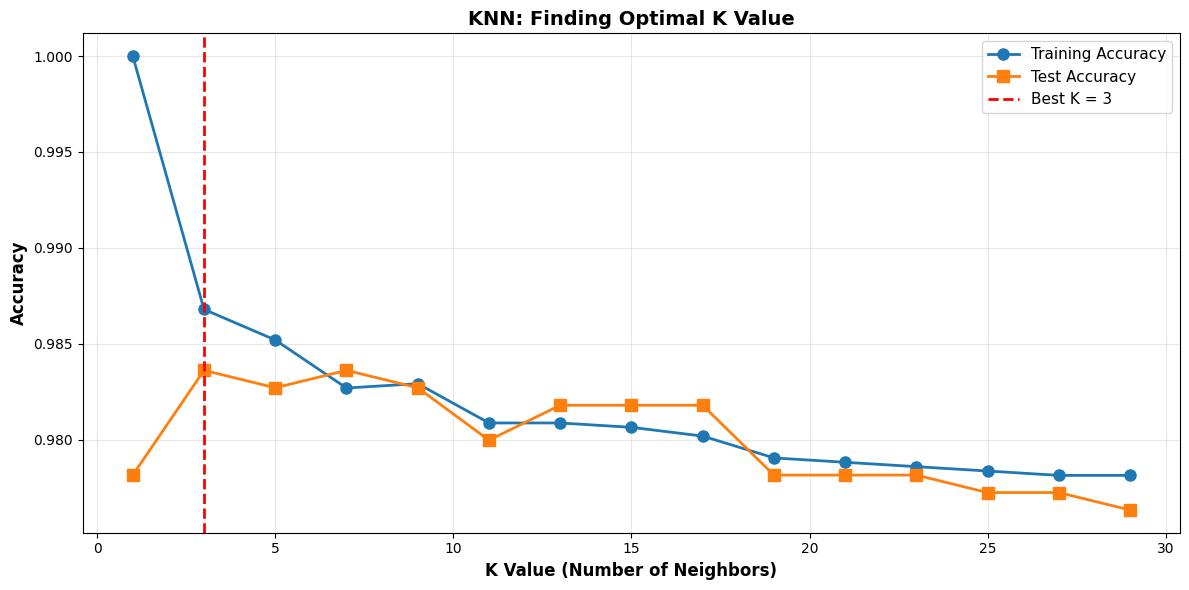


💡 Interpreting the K Value Plot

📊 What You Should See:
 - Training accuracy (blue line): Generally decreases as K increases
 - Test accuracy (orange line): Increases then decreases (optimal K exists)
 - Red dashed line: Marks the optimal K value

🔍 Key Observations:
 - K=1: High training accuracy, lower test accuracy (overfitting)
 - K too large: Lower accuracy on both (underfitting)
 - Optimal K=3: Best balance (test accuracy: 98.36%)

📚 Learning Points:
 - Small K: Model is too sensitive to noise (overfitting)
 - Large K: Model loses local patterns (underfitting)
 - Optimal K: Balances bias and variance for best generalization

💡 For GDI Financial Fraud Detection:
 - Optimal K=3 gives best fraud detection performance
 - Balance between catching fraud (recall) and avoiding false alarms (precision)
 - K too small: Too sensitive to individual transaction noise
 - K too large: Misses local fraud patterns


In [4]:
# Find the optimal K value
# We'll test different K values and see which gives best performance
print("\n" + "=" * 60)
print("Finding Optimal K Value")
print("=" * 60)

# Test different K values
k_values = range(1, 31, 2) # Test odd numbers from 1 to 29
train_scores = []
test_scores = []

print(f"\n🔍 Testing K values from 1 to 29 (odd numbers only)...")
print(f" Why odd? Avoids ties in binary classification!")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Find best K
best_k_idx = np.argmax(test_scores)
best_k = k_values[best_k_idx]
best_test_acc = test_scores[best_k_idx]

print(f"\n✅ Best K value: {best_k}")
print(f" Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")

# Visualize K vs Accuracy
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(k_values, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='r', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
plt.xlabel('K Value (Number of Neighbors)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('KNN: Finding Optimal K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n" + "=" * 60)
print("💡 Interpreting the K Value Plot")
print("=" * 60)
print(f"\n📊 What You Should See:")
print(f" - Training accuracy (blue line): Generally decreases as K increases")
print(f" - Test accuracy (orange line): Increases then decreases (optimal K exists)")
print(f" - Red dashed line: Marks the optimal K value")
print(f"\n🔍 Key Observations:")
print(f" - K=1: High training accuracy, lower test accuracy (overfitting)")
print(f" - K too large: Lower accuracy on both (underfitting)")
print(f" - Optimal K={best_k}: Best balance (test accuracy: {best_test_acc*100:.2f}%)")
print(f"\n📚 Learning Points:")
print(f" - Small K: Model is too sensitive to noise (overfitting)")
print(f" - Large K: Model loses local patterns (underfitting)")
print(f" - Optimal K: Balances bias and variance for best generalization")
print(f"\n💡 For GDI Financial Fraud Detection:")
print(f" - Optimal K={best_k} gives best fraud detection performance")
print(f" - Balance between catching fraud (recall) and avoiding false alarms (precision)")
print(f" - K too small: Too sensitive to individual transaction noise")
print(f" - K too large: Misses local fraud patterns")

## Step 4: Train Final KNN Model and Evaluate

**BEFORE**: We found the optimal K value and understand why it works.

**AFTER**: We'll train the final model with optimal K and evaluate it comprehensively!

**Why this step matters**: 
- We've done the hard work (scaling + finding optimal K)
- **Now** we train the final model and see how well it performs
- Comprehensive evaluation shows the complete picture of model performance

**Why comprehensive evaluation matters**: 
- Accuracy alone doesn't tell the full story
- Precision, Recall, F1, and Confusion Matrix give complete picture
- ROC Curve shows model's ability to separate classes
- For GDI fraud detection: We need to balance catching fraud vs avoiding false alarms


Training Final KNN Model with Optimal K

✅ Final KNN model trained with K=3

📊 Comprehensive Evaluation (Test Set):
 Accuracy: 0.9836 (98.36%)
 Precision: 0.9762 (of predicted fraud, how many are real fraud?)
 Recall: 0.8367 (of real fraud, how many did we catch?)
 F1-Score: 0.9011 (balance of precision and recall)
 ROC-AUC: 0.9515 (ability to separate the two classes)

📋 Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       0.98      1.00      0.99      1001
     Fraud (1)       0.98      0.84      0.90        98

      accuracy                           0.98      1099
     macro avg       0.98      0.92      0.95      1099
  weighted avg       0.98      0.98      0.98      1099



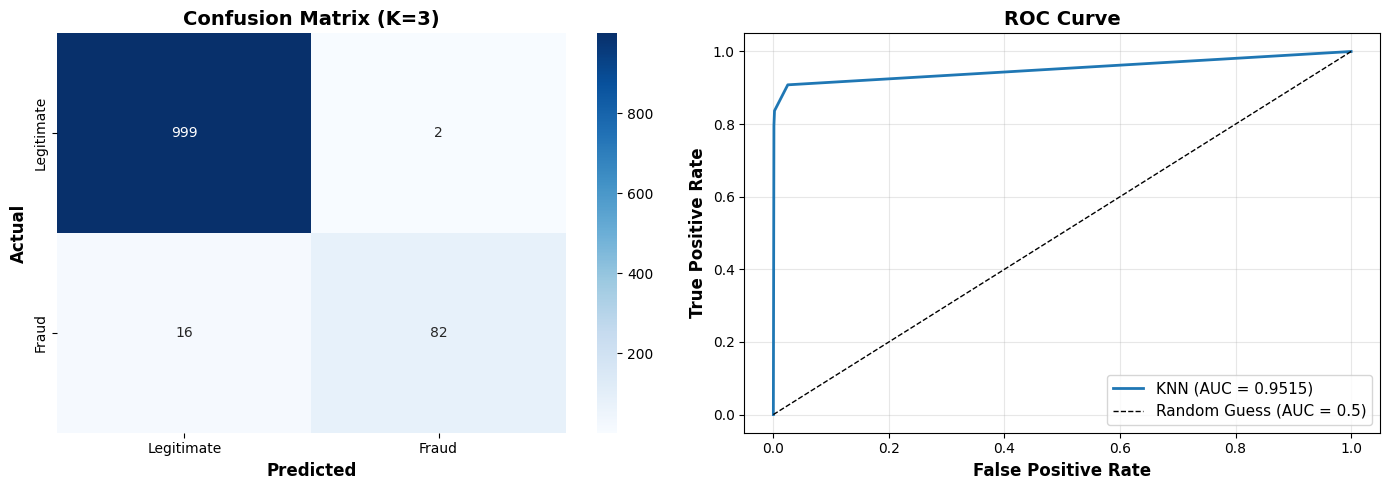


💡 For GDI Financial Fraud Detection:
 - Recall 83.7%: fraction of fraudulent transactions we caught
 - Precision 97.6%: fraction of fraud alerts that are real fraud
 - The confusion matrix shows exactly where the model makes mistakes


In [5]:
# Train final KNN model with optimal K and evaluate comprehensively
print("\n" + "=" * 60)
print("Training Final KNN Model with Optimal K")
print("=" * 60)

# Train the final model using the optimal K found in Step 3
# Remember: KNN is lazy learning - "training" just stores the scaled training data!
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
print(f"\n✅ Final KNN model trained with K={best_k}")

# Predictions on the test set
y_pred = knn_final.predict(X_test_scaled)
# Probability of fraud = fraction of the K neighbors that are fraud (used for ROC curve)
y_proba = knn_final.predict_proba(X_test_scaled)[:, 1]

# Comprehensive evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"\n📊 Comprehensive Evaluation (Test Set):")
print(f" Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision: {precision:.4f} (of predicted fraud, how many are real fraud?)")
print(f" Recall: {recall:.4f} (of real fraud, how many did we catch?)")
print(f" F1-Score: {f1:.4f} (balance of precision and recall)")
print(f" ROC-AUC: {auc_score:.4f} (ability to separate the two classes)")

# Detailed per-class report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Legitimate (0)", "Fraud (1)"]))

# Confusion matrix + ROC curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"])
axes[0].set_xlabel("Predicted", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Actual", fontsize=12, fontweight="bold")
axes[0].set_title(f"Confusion Matrix (K={best_k})", fontsize=14, fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f"KNN (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess (AUC = 0.5)")
axes[1].set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
axes[1].set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
axes[1].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n💡 For GDI Financial Fraud Detection:")
print(f" - Recall {recall*100:.1f}%: fraction of fraudulent transactions we caught")
print(f" - Precision {precision*100:.1f}%: fraction of fraud alerts that are real fraud")
print(f" - The confusion matrix shows exactly where the model makes mistakes")

## Part 3: Decision Framework

## Step 5: When to Use KNN vs Other Algorithms

**BEFORE**: We understand how KNN works.

**AFTER**: We'll understand when KNN is the right choice and when to use other algorithms!

**Decision Framework:**

| Scenario | Best Algorithm | Why |
|----------|---------------|-----|
| **Small dataset, interpretability important** | Decision Trees | Easy to understand |
| **Large dataset, need fast predictions** | Logistic Regression | Fast, efficient |
| **Non-linear patterns, need optimal margin** | SVM | Maximum margin boundaries |
| **No clear pattern, need simple solution** | KNN | Simple, no assumptions |
| **Need feature importance** | Random Forest | Built-in feature importance |
| **Lazy learning acceptable** | KNN | No training phase needed |

**KNN Advantages:**
- ✅ Simple to understand and implement
- ✅ No assumptions about data distribution
- ✅ Works well for non-linear patterns
- ✅ Can be used for both classification and regression

**KNN Disadvantages:**
- ❌ Slow prediction (must compute distances to all training points)
- ❌ Sensitive to irrelevant features
- ❌ Requires feature scaling
- ❌ Memory intensive (stores all training data)
- ❌ Sensitive to K value choice

## Summary

### What We Learned

1. **KNN Basics**: KNN finds K nearest neighbors and predicts based on majority vote
2. **Feature Scaling**: CRITICAL for KNN - always use StandardScaler!
3. **Choosing K**: Balance between overfitting (small K) and underfitting (large K)
4. **Lazy Learning**: KNN doesn't train a model - all computation happens during prediction
5. **Distance Metrics**: Euclidean distance (default) measures "nearest"
6. **When to Use**: Simple solution, no assumptions, non-linear patterns

### Key Takeaways

- ⚠️ **Always scale features before KNN** - distance calculations depend on feature scales
- 🎯 **Choose K carefully** - too small = overfitting, too large = underfitting
- 💡 **KNN is simple but powerful** - often performs well with proper preprocessing
- 📊 **Evaluate comprehensively** - use accuracy, precision, recall, F1, AUC, confusion matrix
- 🔍 **Understand trade-offs** - KNN is slow for large datasets but simple to understand

### Next Steps

- 📓 **Unit 4: Clustering** - K-Means uses similar distance concepts
- 📓 **Unit 5: Model Selection** - Hyperparameter tuning for K
- 📓 **Advanced Topics** - Weighted KNN, distance metrics, approximate nearest neighbors

---

**Congratulations!** 🎉 You've completed all classification algorithms in Unit 3!

## 📚 References

1. Fix, E., & Hodges, J. L. (1951). *Discriminatory Analysis: Nonparametric Discrimination: Consistency Properties*. USAF School of Aviation Medicine, Report 4.
2. Cover, T., & Hart, P. (1967). *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory, 13(1), 21–27.
3. Malkov, Y. A., & Yashunin, D. A. (2020). *Efficient and Robust Approximate Nearest Neighbor Search Using Hierarchical Navigable Small World Graphs*. IEEE TPAMI, 42(4). <https://arxiv.org/abs/1603.09320>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapters 2 and 4. Springer.
